In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Datos de entrenamiento

In [2]:
!gsutil -m cp gs://3d-shapes/3dshapes.h5 .

Copying gs://3d-shapes/3dshapes.h5...
==> NOTE: You are downloading one or more large file(s), which would
run significantly faster if you enabled sliced object downloads. This
feature is enabled by default but requires that compiled crcmod be
installed (see "gsutil help crcmod").

/ [1/1 files][255.2 MiB/255.2 MiB] 100% Done  22.5 MiB/s ETA 00:00:00           
Operation completed over 1 objects/255.2 MiB.                                    


### Clase para el dataset

In [3]:
class Shapes3D(Dataset):

    def __init__(self, filename, max_samples=None, seed=0):

        with h5py.File(filename, 'r') as file:
            all_labels = file['labels'][:]
            all_images = file['images'][:]

        if max_samples is not None and max_samples < len(all_images):
            rng = np.random.default_rng(seed)
            indices = rng.choice(len(all_images), size=max_samples, replace=False)
            all_labels = all_labels[indices]
            all_images = all_images[indices]

        self.images = (all_images.astype(np.float32) / 255).transpose(0, 3, 1, 2)
        self.labels = all_labels.astype(np.float32)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, n):
        img = torch.from_numpy(self.images[n])
        label = torch.from_numpy(self.labels[n])
        return img, label

In [4]:
batch_size = 128
max_samples = 100_000

dataset = Shapes3D(filename='3dshapes.h5', max_samples=max_samples)
dataloader = DataLoader(dataset, batch_size, shuffle=True, num_workers=2, pin_memory=True)

### Visualización

In [5]:
def show_images(imgs, ncols=None):
    imgs = imgs.permute(0, 2, 3, 1).detach().cpu()
    n_images = imgs.shape[0]
    ncols = ncols or int(n_images**0.5)
    nrows = -(-n_images // ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2, nrows * 2))
    for ax, img in zip(axes.flat, imgs):
        ax.imshow(img)
        ax.axis('off')
    for ax in axes.flat[n_images:]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

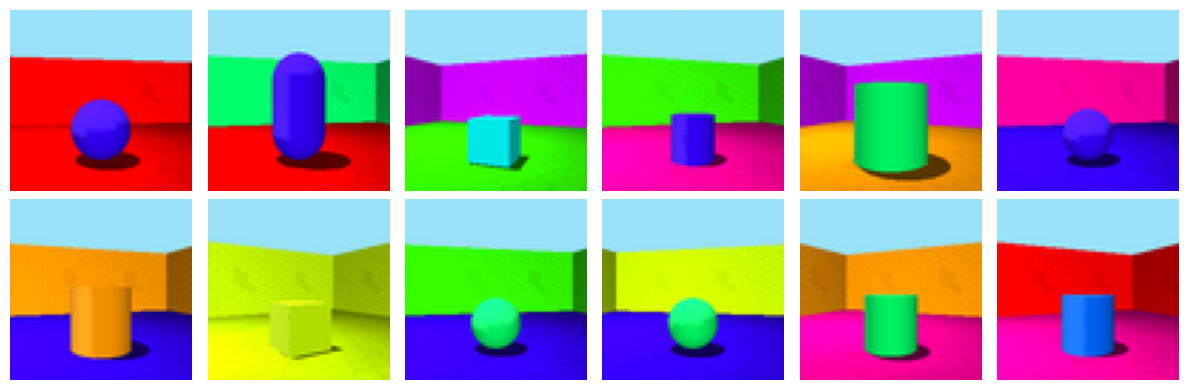

In [6]:
imgs, labels = next(iter(dataloader))
assert imgs.shape == (batch_size, 3, 64, 64)
assert labels.shape == (batch_size, 6)

show_images(imgs[:12], ncols=6)

## Red neuronal y entrenamiento

### Clase `VAE` incondicional

In [7]:
class VAE(nn.Module):

    def __init__(self, latent_dim):
        super().__init__()
        self.latent_dim = latent_dim

        self.enc = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),
            nn.GroupNorm(8, 64), nn.SiLU(),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.GroupNorm(8, 128), nn.SiLU(),
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.GroupNorm(8, 256), nn.SiLU(),
            nn.Conv2d(256, 512, 4, 2, 1),
            nn.GroupNorm(8, 512), nn.SiLU(),
            nn.Flatten(),
            nn.Linear(512 * 4 * 4, 2 * latent_dim)
        )

        self.dec = nn.Sequential(
            nn.Linear(latent_dim, 512 * 4 * 4),
            nn.Unflatten(1, (512, 4, 4)),
            nn.ConvTranspose2d(512, 256, 4, 2, 1),
            nn.GroupNorm(8, 256), nn.SiLU(),
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.GroupNorm(8, 128), nn.SiLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.GroupNorm(8, 64), nn.SiLU(),
            nn.ConvTranspose2d(64, 3, 4, 2, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        h = self.enc(x)
        mu, log_std = h.chunk(2, dim=-1)
        std = torch.exp(log_std)
        eps = torch.randn_like(std)
        z = mu + eps * std
        x_dec = self.dec(z)
        return (mu, std), x_dec

### Loop de entrenamiento

In [8]:
def train_vae(model, dataloader, optimizer, reconstruction_metric, beta, n_epochs):

    model = model.to(DEVICE)
    model.train()

    total_steps = n_epochs * len(dataloader)
    global_bar = tqdm(total=total_steps, desc='Entrenamiento', position=0)

    reconstruction_log, prior_matching_log = [], []

    try:
        for epoch in range(1, n_epochs + 1):
            total_reconstruction, total_prior_matching = 0, 0

            for x, _ in dataloader:
                x = x.to(DEVICE)

                # Entrenamiento ------------------------------------------------

                (mu, std), x_dec = model(x)

                # Loss:

                if reconstruction_metric == 'bce':
                    reconstruction = F.binary_cross_entropy(x_dec, x, reduction='sum')
                elif reconstruction_metric == 'mse':
                    reconstruction = F.mse_loss(x_dec, x, reduction='sum')
                elif reconstruction_metric == 'l1':
                    reconstruction = F.l1_loss(x_dec, x, reduction='sum')

                prior_matching = - 0.5 * torch.sum(1 + 2 * std.log() - mu.pow(2) - std.pow(2))

                loss = reconstruction + beta * prior_matching

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                # Registro -----------------------------------------------------

                total_reconstruction += reconstruction.item()
                total_prior_matching += prior_matching.item()

                global_bar.update(1)
                global_bar.set_postfix({
                    'época': epoch,
                    'reconstrucción': total_reconstruction / len(dataloader.dataset),
                    'prior matching': total_prior_matching / len(dataloader.dataset)
                })

            N = len(dataloader.dataset)
            reconstruction_log.append(total_reconstruction / N)
            prior_matching_log.append(total_prior_matching / N)

    except KeyboardInterrupt:
        print('Entrenamiento interrumpido.')

    finally:
        global_bar.close()

        # Gráfico --------------------------------------------------------------

        fig, ax1 = plt.subplots(figsize=(10, 4))

        ax1.set_xlabel('Época')
        ax1.set_ylabel('', color='red')
        l1, = ax1.plot(reconstruction_log, label='Término de reconstrucción', color='red')
        ax1.tick_params(axis='y', labelcolor='red')

        ax2 = ax1.twinx()
        ax2.set_ylabel('', color='blue')
        l2, = ax2.plot(prior_matching_log, label='Prior matching', color='blue')
        ax2.tick_params(axis='y', labelcolor='blue')

        lines = [l1, l2]
        labels = [line.get_label() for line in lines]
        ax1.legend(lines, labels)

        plt.title('Dinámica de entrenamiento')
        fig.tight_layout()
        plt.show()

Entrenamiento:   0%|          | 0/7820 [00:00<?, ?it/s]

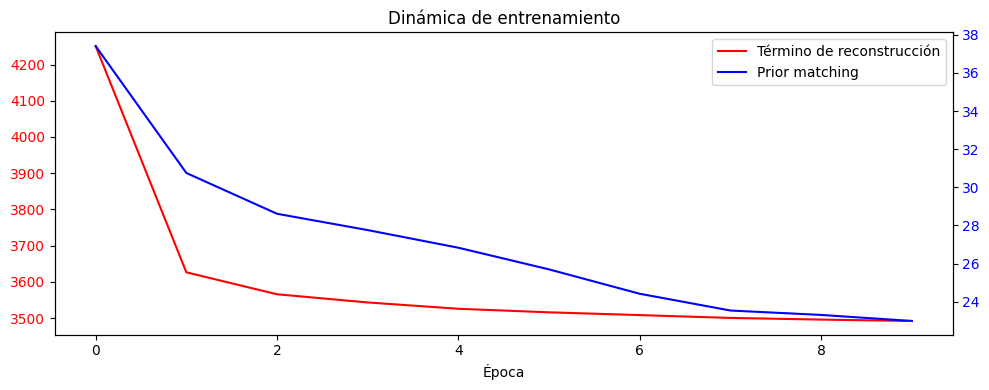

In [9]:
latent_dim = 32
reconstruction_metric = 'bce'
beta = 4
n_epochs = 10

model = VAE(latent_dim)
optimizer = torch.optim.Adam(model.parameters())

train_vae(model, dataloader, optimizer, reconstruction_metric, beta, n_epochs)

## Tareas de generación

### Reconstrucción

In [10]:
def reconstruction(x, model):
    model.eval()
    x = x.to(DEVICE)
    with torch.no_grad():
        (_, _), x_dec = model(x)
    return x_dec.cpu()

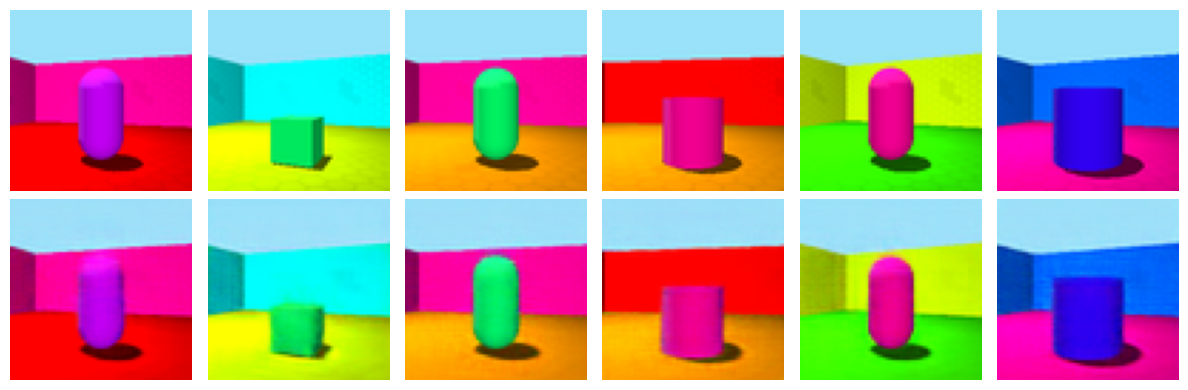

In [11]:
imgs, _ = next(iter(dataloader))

x_original = imgs[:6]
x_reconstruction = reconstruction(x_original, model)

show_images(torch.cat([x_original, x_reconstruction], dim=0), ncols=len(x_original))

### Generación de nuevas muestras

In [12]:
def generate_samples(model, n_samples):
    model.eval()
    with torch.no_grad():
        z = torch.randn(n_samples, model.latent_dim, device=DEVICE)
        samples = model.dec(z)
    return samples.cpu()

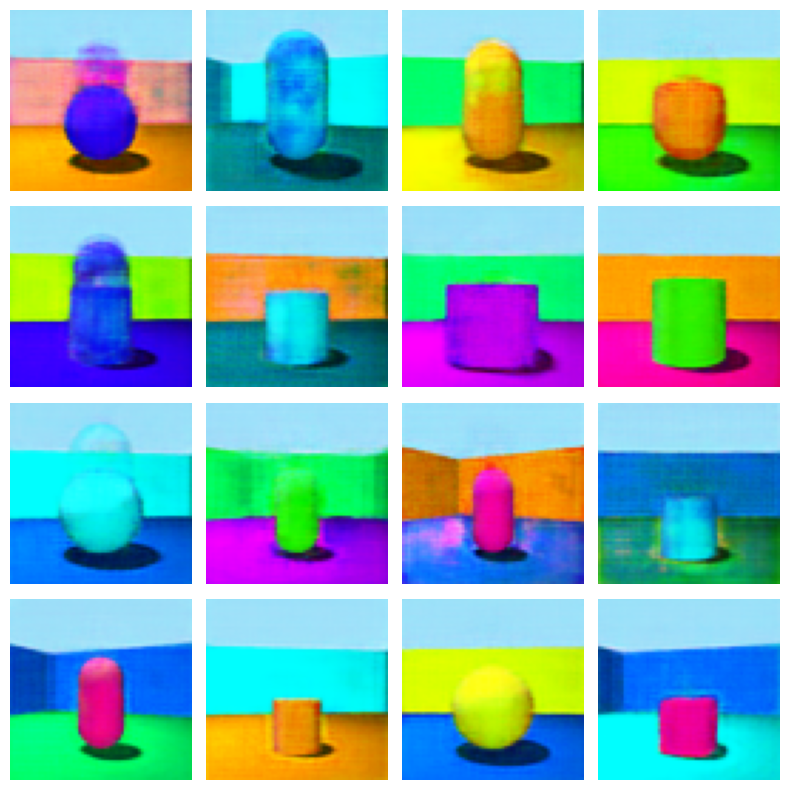

In [13]:
samples = generate_samples(model, n_samples=16)
show_images(samples)

### Interpolación

#### Interpolación en el espacio de pixeles

In [14]:
def interpolate_pixels(x1, x2, steps=8):
    alphas = torch.linspace(0, 1, steps).view(-1, 1, 1, 1)
    interpolated = (1 - alphas) * x1 + alphas * x2
    return interpolated

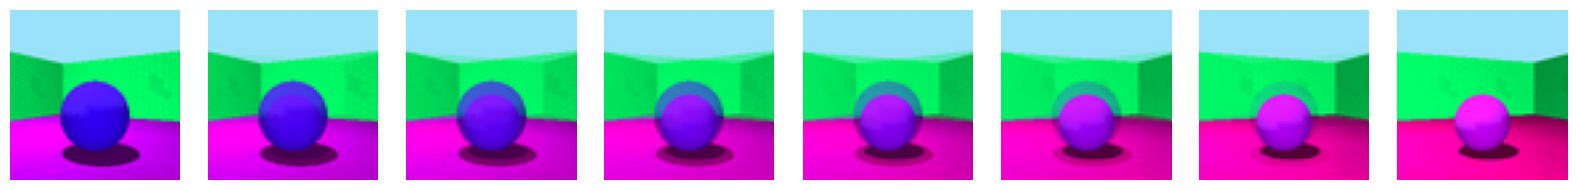

In [15]:
imgs, _ = next(iter(dataloader))

x1, x2 = imgs[0:2]
pixel_interpolation = interpolate_pixels(x1, x2, steps=8)

show_images(pixel_interpolation, ncols=len(pixel_interpolation))

#### Interpolación en el espacio latente

In [16]:
def interpolate_latents(x1, x2, model, steps=8):
    model.eval()
    x = torch.stack([x1, x2]).to(DEVICE)
    with torch.no_grad():
        (mu, _), _ = model(x)
        alphas = torch.linspace(0, 1, steps, device=DEVICE).unsqueeze(1)
        z = (1 - alphas) * mu[0] + alphas * mu[1]
        return model.dec(z).cpu()

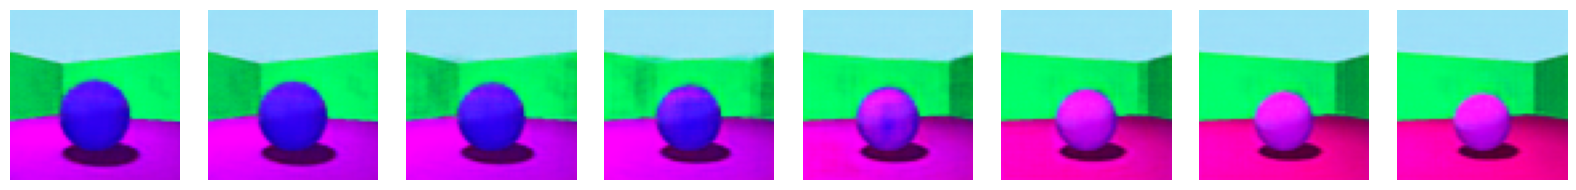

In [17]:
imgs, _ = next(iter(dataloader))

# Se interpolan las mismas imágenes usadas en interpolate_pixels:
pixel_interpolation = interpolate_latents(x1, x2, model)

show_images(pixel_interpolation, ncols=len(pixel_interpolation))

### Aritmética en el espacio latente

In [18]:
def attribute_arithmetic(model, dataset, source_attributes, target_attributes, test_img, ponderators):

    model.eval()
    _FACTORS_IN_ORDER = ['floor_hue', 'wall_hue', 'object_hue', 'scale', 'shape', 'orientation']

    def get_indices(atributos):
        dataset_labels = torch.stack([dataset[n][1] for n in range(len(dataset))])
        mask = torch.ones(len(dataset_labels), dtype=bool)
        for factor, val in atributos.items():
            idx = _FACTORS_IN_ORDER.index(factor)
            mask &= (dataset_labels[:, idx] == val)
        return torch.nonzero(mask).squeeze()

    def mean_latents(indices, batch_size=256):
        mu_list = []
        with torch.no_grad():
            for i in range(0, len(indices), batch_size):
                idx = indices[i:i+batch_size]
                imgs = torch.stack([dataset[n][0] for n in idx]).to(DEVICE)
                mu, _ = model(imgs)[0]
                mu_list.append(mu.cpu())
        return torch.cat(mu_list, dim=0).mean(dim=0)

    with torch.no_grad():

        # Vectores de origen:
        idx_source = get_indices(source_attributes)
        mu_source_mean = mean_latents(idx_source)

        # Vectores de llegada:
        idx_target = get_indices(target_attributes)
        mu_target_mean = mean_latents(idx_target)

        # Vector director y desplazamiento:
        z_test, _ = model(test_img.unsqueeze(0).to(DEVICE))[0]
        delta = (mu_target_mean - mu_source_mean).to(DEVICE)
        ponderators = torch.tensor(ponderators, device=DEVICE).unsqueeze(1)
        displaced_z = z_test + ponderators * delta

        return model.dec(displaced_z).cpu()

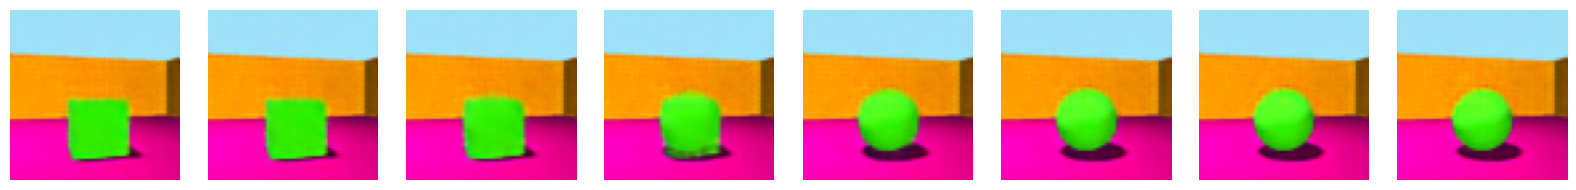

In [19]:
# Imagen de prueba:
test_img, test_label = dataset[2]
ponderators = torch.linspace(0, 1, 8).tolist()

# Transformar forma original (cubo) -> esfera:
source_attributes = {'shape': test_label[4]}
target_attributes = {'shape': 2}

displaced_img = attribute_arithmetic(model, dataset, source_attributes, target_attributes, test_img, ponderators)

show_images(displaced_img, ncols=len(displaced_img))